*Name* : - **Arya Joshi** 

*Roll No.* : - **23B1853**

Acknowledgement :- ChatGPT was used to assist in making this journal report

# **Hydrogen Spectra - Balmer Series**

# Aim

# Apparatus

## Theory

## Observations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

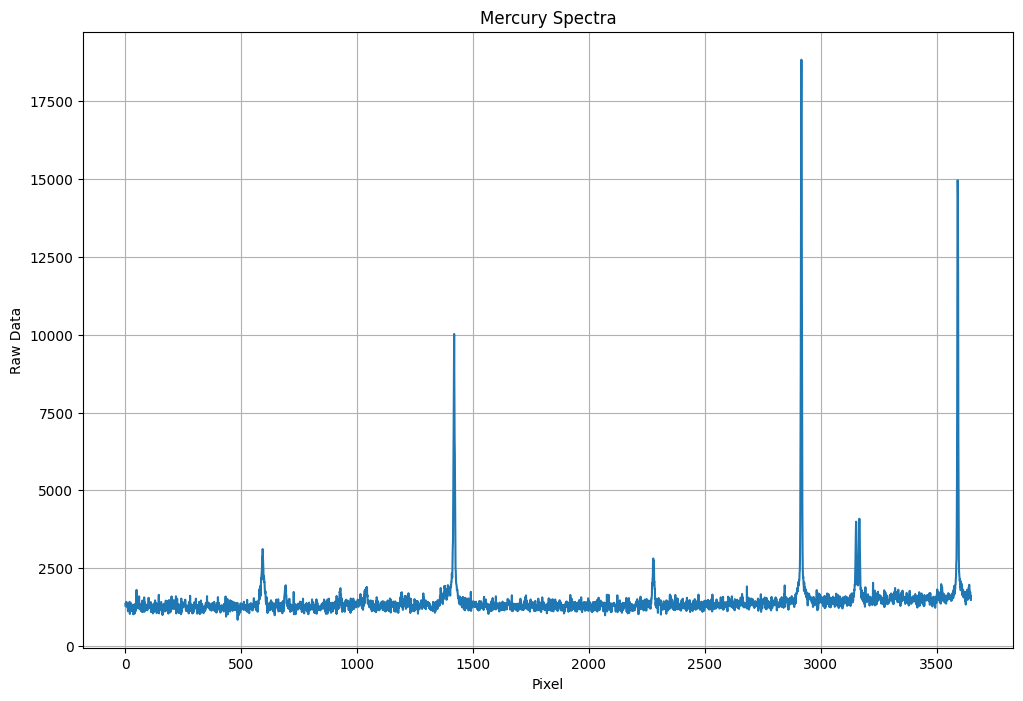

In [45]:
Mercury_spectra = pd.read_excel('Mercury_Data.xlsx')
# print(Mercury_spectra)

plt.figure(figsize=(12, 8))
plt.plot(Mercury_spectra['Pixel'], Mercury_spectra['Raw Data'])
plt.xlabel('Pixel')
plt.ylabel('Raw Data')
plt.title('Mercury Spectra')
plt.grid()
plt.show()

Three peaks at pixels: [ 592 1418 2916]


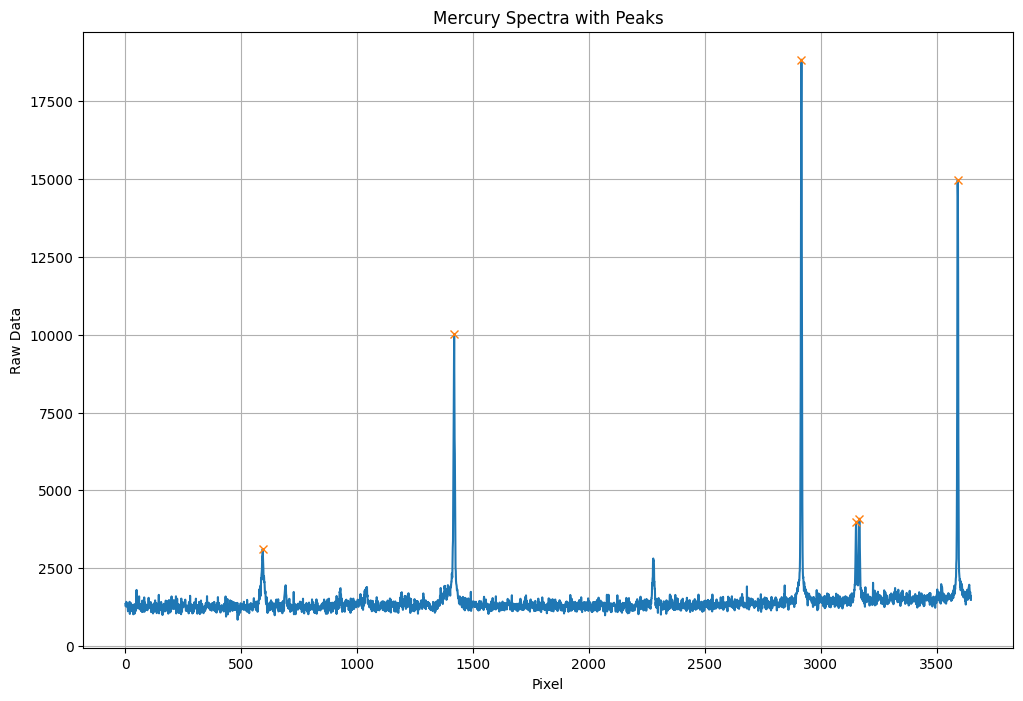

In [47]:
peaks, _ = find_peaks(Mercury_spectra['Raw Data'], height=3000)  # Adjust height as needed
# print("Peaks found at pixels:", peaks)

d = peaks[:3]  # Get the first three peaks
print("Three peaks at pixels:", d)
lambda_values = [404.7 , 435.8, 546.1]  # Known wavelengths for Mercury peaks

plt.figure(figsize=(12, 8))
plt.plot(Mercury_spectra['Pixel'], Mercury_spectra['Raw Data'])
plt.plot(Mercury_spectra['Pixel'][peaks], Mercury_spectra['Raw Data'][peaks], "x")
plt.xlabel('Pixel')
plt.ylabel('Raw Data')
plt.title('Mercury Spectra with Peaks')
plt.grid()
plt.show()

In [48]:
A = (lambda_values[1] - lambda_values[0]) / (lambda_values[2] - lambda_values[0])
B = (d[1] - d[0]) / (d[2] - d[0])

lambda_0 = (A*lambda_values[2] - B*lambda_values[1])/(A-B)
d_0 = (B*d[2] - A*d[1])/(B-A)
c = ((lambda_values[1] - lambda_values[0])*(d_0 - d[1])*(d_0 - d[0]))/(d[1] - d[0])
# print(lambda_0, A, B, d_0, c)

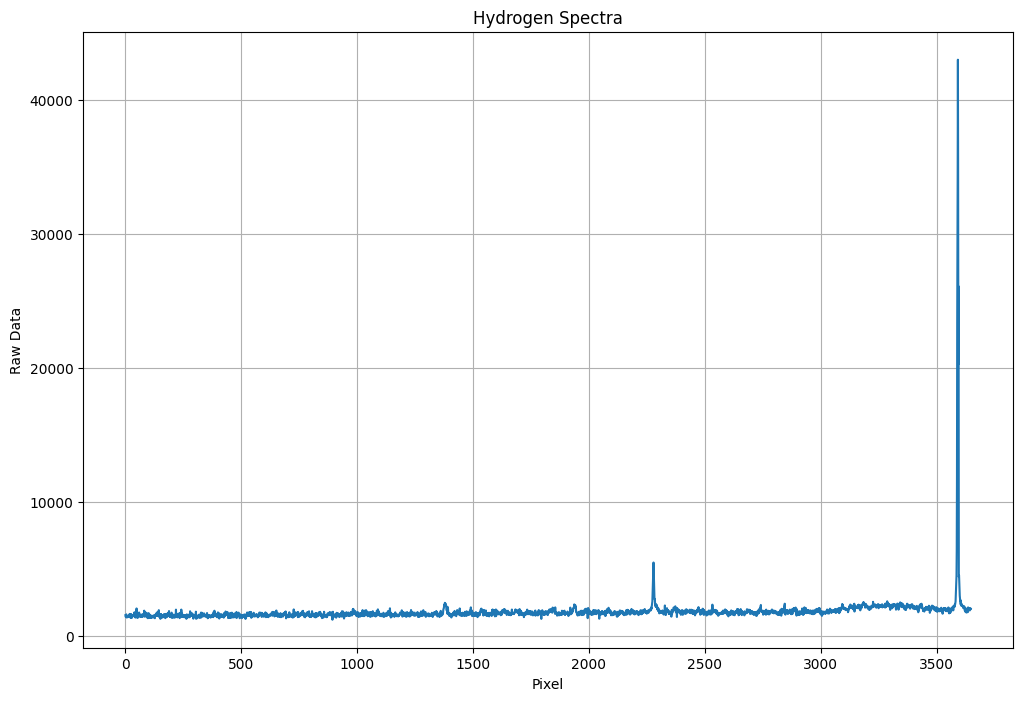

In [50]:
Hydrogen_spectra = pd.read_excel('Hydrogen_data.xlsx')
# print(Hydrogen_spectra)

plt.figure(figsize=(12, 8))
plt.plot(Hydrogen_spectra['Pixel'], Hydrogen_spectra['Raw Data'])
plt.xlabel('Pixel') 
plt.ylabel('Raw Data')
plt.title('Hydrogen Spectra')
plt.grid()
plt.show()

Peaks found at pixels in Hydrogen spectra: [1378 2278 2284 3182 3184 3186 3225 3284 3286 3290 3342 3344 3348 3591
 3594 3596 3602 3604]
Three highest peaks at pixels: 3591
Selected peaks at pixels: [1378 2278 3591]


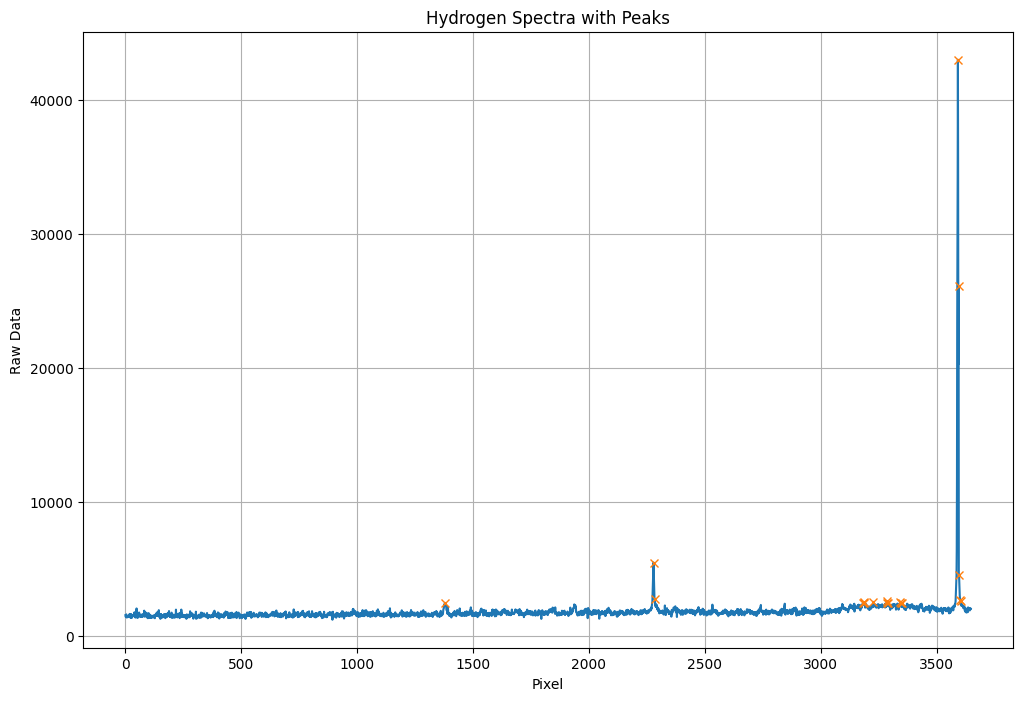

In [51]:
peaks_h, _ = find_peaks(Hydrogen_spectra['Raw Data'], height=2400)  # Adjust height as needed
print("Peaks found at pixels in Hydrogen spectra:", peaks_h)

highest_peak = peaks_h[np.argsort(Hydrogen_spectra['Raw Data'][peaks_h])][-1:]  # Get the three highest peaks
print("Three highest peaks at pixels:", highest_peak[0])

d_h = peaks_h[:2]  # Get the first two peaks and the highest peak
d_h = np.append(d_h, highest_peak[0])
print("Selected peaks at pixels:", d_h)

plt.figure(figsize=(12, 8))
plt.plot(Hydrogen_spectra['Pixel'], Hydrogen_spectra['Raw Data'])  # Zoom in on the region of interest
plt.plot(Hydrogen_spectra['Pixel'][peaks_h], Hydrogen_spectra['Raw Data'][peaks_h], "x")
plt.xlabel('Pixel')
plt.ylabel('Raw Data')
plt.title('Hydrogen Spectra with Peaks')
plt.grid()
plt.show()

In [55]:
lambda_h = lambda_0 + c / (d_0 - d_h)
print("Calculated wavelengths for Hydrogen peaks:", lambda_h)

Transition_higher_levels = [5, 4, 3]  # Corresponding to the selected peaks

Rydberg_constants = 1 / (lambda_h * (1/4 - 1/np.array(Transition_higher_levels)**2))
print("Calculated Rydberg constants for Hydrogen peaks (in nm^-1):", Rydberg_constants)

Avg_Rydberg_constant = np.mean(Rydberg_constants)
print(f"Average Rydberg constant: {Avg_Rydberg_constant:.6f} nm^-1 or {Avg_Rydberg_constant * 1e9:.4e} m^-1")

Calculated wavelengths for Hydrogen peaks: [433.99576657 485.96319434 657.27220527]
Calculated Rydberg constants for Hydrogen peaks (in nm^-1): [0.01097224 0.01097477 0.01095437]
Average Rydberg constant: 0.010967 nm^-1 or 1.0967e+07 m^-1


## Results

In [ ]:
print("Calculated wavelengths for Hydrogen peaks (nm):", lambda_h)
print("---------------------------------------------------------------")
print("Calculated Rydberg constants for Hydrogen peaks (nm^-1):", Rydberg_constants)
print("----------------------------------------------------------------")
print(f"Average Rydberg constant: {Avg_Rydberg_constant:.6f} nm^-1 or {Avg_Rydberg_constant * 1e9:.4e} m^-1")

Calculated wavelengths for Hydrogen peaks (nm): [433.99576657 485.96319434 657.27220527]
---------------------------------------------------------------
Calculated Rydberg constants for Hydrogen peaks (nm^-1): [0.01097224 0.01097477 0.01095437]
----------------------------------------------------------------
Average Rydberg constant: 0.010967 nm^-1 or 1.0967e+07 m^-1
